# Load Dataset

In [5]:
# List of query languages
languages = ['sl', 'ur', 'sw', 'uz', 'vi', 'sq', 'ms', 'km', 'hy', 'da', 'ky',
            'mg', 'mn', 'ja', 'el', 'it', 'is', 'ru', 'tl', 'so', 'pt', 'uk',
            'sr', 'sn', 'ht', 'bs', 'my', 'ar', 'hr', 'nl', 'bn', 'ne', 'hi',
            'ka', 'az', 'ko', 'id', 'fr', 'es', 'en', 'fa', 'lo', 'iw', 'th',
            'tr', 'zht', 'zhs', 'ti', 'tg']

In [6]:
import os
from collections import Counter, defaultdict
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

# Dictionary to store datasets
datasets_dict = {}

# Loop over each language and load the dataset
for lang in languages:
    # Load the dataset for the current language and store it in the dictionary
    datasets_dict[lang] = load_dataset('borderlines/bordirlines', lang, trust_remote_code=True)

/home1/f/fionaluo/miniconda3/envs/borderlines/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating openai.qlang split: 50 examples [00:00, 92.83 examples/s]
Generating openai.qlang_en split: 50 examples [00:00, 100.05 examples/s]
Generating openai.en split: 50 examples [00:00, 103.08 examples/s]
Generating openai.rel_langs split: 50 examples [00:00, 104.59 examples/s]
Generating m3.qlang split: 50 examples [00:00, 105.08 examples/s]
Generating m3.qlang_en split: 50 examples [00:00, 106.39 examples/s]
Generating m3.en split: 50 examples [00:00, 84.70 examples/s]
Generating m3.rel_langs split: 50 examples [00:00, 105.59 examples/s]
Generating openai.qlang split: 40 examples [00:00, 82.40 examples/s]
Generating openai.qlang_en split: 40 examples [00:00, 80.89 examples/s]
Generating openai.en split: 4

If `query_lang_counts.json` does not exist, you should first run `information_retrieval/query_lang_count.py`. This will store the json under the `information_retrieval` folder.

In [7]:
import json

json_file_path = '../information_retrieval/query_lang_counts.json'

with open(json_file_path, 'r') as file:
    lang_counts = json.load(file)

print(lang_counts)

{'Abyei_en': {'ar': 153, 'en': 333}, 'Heglig_en': {'ar': 156, 'en': 307}, 'Kafia_Kingi_en': {'ar': 148, 'en': 304}, 'Chagos_Archipelago_en': {'mfe': 0, 'fr': 433, 'en': 676}, 'Ilemi_Triangle_en': {'sw': 200, 'en': 358}, 'KaNgwane_en': {'en': 237}, 'Ingwavuma_en': {'en': 232}, 'Logoba_en': {'sw': 97, 'en': 320}, 'Moyo_District_en': {'sw': 101, 'en': 328}, 'Chiengi_en': {'sw': 67, 'en': 121}, 'Lunchinda-Pweto_Province_en': {'sw': 67, 'en': 178}, 'Lunkinda_River_en': {'sw': 67, 'en': 109}, 'Pweto_en': {'sw': 67, 'en': 124}, 'Mbamba_Bay_en': {'sw': 133, 'en': 263}, 'Lake_Nyasa_en': {'sw': 144, 'en': 258}, 'Okpara_River_en': {'fr': 439, 'en': 252}, 'Sindabezi_Island_en': {'sn': 26, 'en': 263}, 'Bajo_Nuevo_Bank_en': {'es': 706, 'en': 642}, 'Navassa_Island_en': {'ht': 87, 'en': 413}, 'Sapodilla_Cayes_en': {'es': 815, 'en': 477}, 'Serranilla_Bank_en': {'es': 883, 'en': 627}, 'Guayana_Esequiba_en': {'es': 361, 'en': 370}, 'Essequibo_River_en': {'es': 363, 'en': 329}, 'Ankoko_Island/Isla_de_Anac

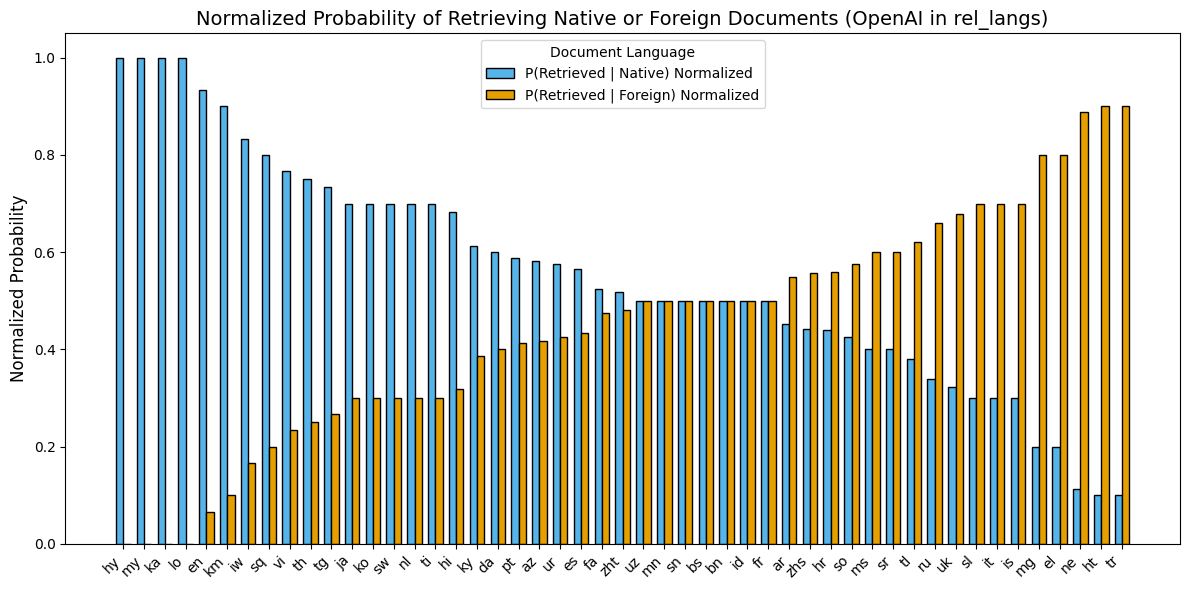

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Initialize counters for query and foreign language document occurrences
native_lang_retrieved_count = defaultdict(int)
foreign_lang_retrieved_count = defaultdict(int)
native_lang_count = defaultdict(int)
foreign_lang_count = defaultdict(int)

# Iterate through each language in the languages list
for lang in languages:
    for row in datasets_dict[lang]['openai.rel_langs']:
        query_id = row['territory'] + '_' + lang
        # Check if the document language matches the query language
        if row['doc_lang'] == lang:
            native_lang_retrieved_count[lang] += 1
            native_lang_count[lang] += lang_counts[query_id][lang]
        else:
            foreign_lang_retrieved_count[lang] += 1
            foreign_lang_count[lang] += sum(lang_counts[query_id][key] for key in lang_counts[query_id] if key != lang)

# Calculate total counts
total_native_retrieved = sum(native_lang_retrieved_count.values())
total_native_count = sum(native_lang_count.values())
total_foreign_retrieved = sum(foreign_lang_retrieved_count.values())
total_foreign_count = sum(foreign_lang_count.values())

# Calculate the total number of documents
total_documents = total_native_count + total_foreign_count

# Prepare data for plotting
results = []
overall_retrieved = defaultdict(int)

for lang in languages:
    if lang in native_lang_retrieved_count:  # Ensure the language is in the retrieved count
        # Calculate P(Retrieved | Native)
        p_retrieved_given_native = native_lang_retrieved_count[lang] / total_documents if total_documents > 0 else 0

        # Calculate P(Retrieved | Foreign)
        p_retrieved_given_foreign = foreign_lang_retrieved_count[lang] / total_documents if total_documents > 0 else 0

        # Calculate overall P(Retrieved)
        overall_retrieved[lang] = (native_lang_retrieved_count[lang] + foreign_lang_retrieved_count[lang]) / total_documents if total_documents > 0 else 0

        # Normalize the probabilities
        normalized_native = p_retrieved_given_native / overall_retrieved[lang] if overall_retrieved[lang] > 0 else 0
        normalized_foreign = p_retrieved_given_foreign / overall_retrieved[lang] if overall_retrieved[lang] > 0 else 0

        results.append((lang, normalized_native, normalized_foreign))

# Sort results by normalized P(Retrieved | Native) in reverse order
results.sort(key=lambda x: x[1], reverse=True)  # Sort in reverse order

# Data for plotting
labels = [lang for lang, _, _ in results]
normalized_native_probs = [native for _, native, _ in results]
normalized_foreign_probs = [foreign for _, _, foreign in results]

# Set up the bar positions
bar_width = 0.35
x = np.arange(len(labels))

# Plotting the results
plt.figure(figsize=(12, 6))
plt.bar(x - bar_width/2, normalized_native_probs, bar_width, label='P(Retrieved | Native) Normalized', color='#56B4E9', edgecolor='black')
plt.bar(x + bar_width/2, normalized_foreign_probs, bar_width, label='P(Retrieved | Foreign) Normalized', color='#E69F00', edgecolor='black')

# Adding labels and title
plt.ylabel('Normalized Probability', fontsize=12)
plt.title('Normalized Probability of Retrieving Native or Foreign Documents (OpenAI in rel_langs)', fontsize=14)
plt.xticks(x, labels, rotation=45, ha='right', fontsize=10)
plt.legend(title="Document Language", fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()

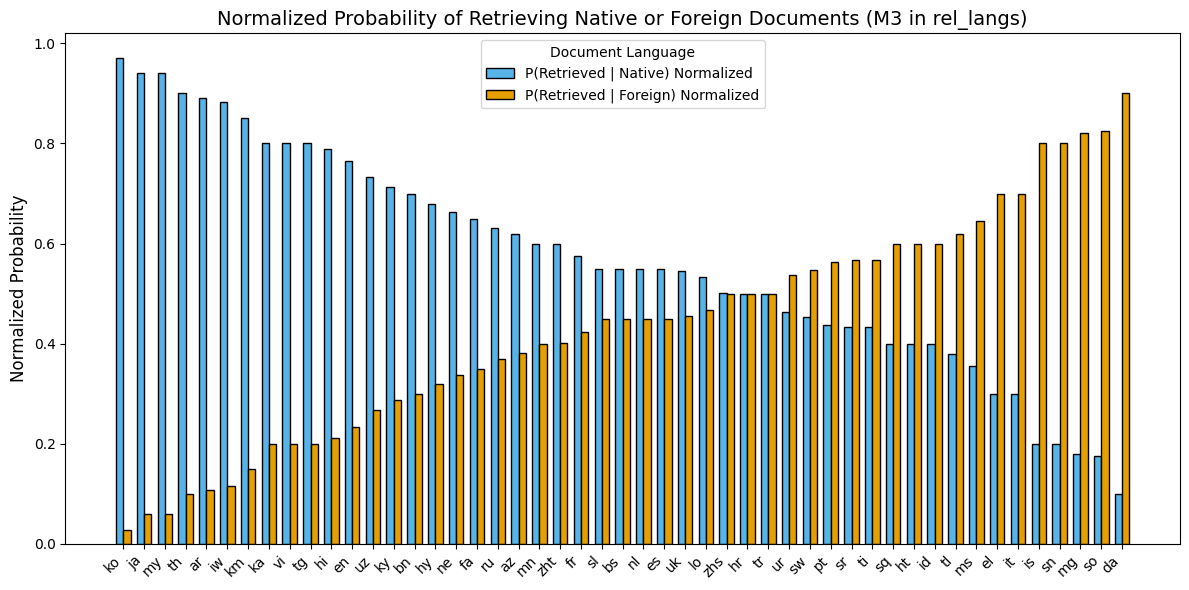

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Initialize counters for query and foreign language document occurrences
native_lang_retrieved_count = defaultdict(int)
foreign_lang_retrieved_count = defaultdict(int)
native_lang_count = defaultdict(int)
foreign_lang_count = defaultdict(int)

# Iterate through each language in the languages list
for lang in languages:
    for row in datasets_dict[lang]['m3.rel_langs']:
        query_id = row['territory'] + '_' + lang
        # Check if the document language matches the query language
        if row['doc_lang'] == lang:
            native_lang_retrieved_count[lang] += 1
            native_lang_count[lang] += lang_counts[query_id][lang]
        else:
            foreign_lang_retrieved_count[lang] += 1
            foreign_lang_count[lang] += sum(lang_counts[query_id][key] for key in lang_counts[query_id] if key != lang)

# Calculate total counts
total_native_retrieved = sum(native_lang_retrieved_count.values())
total_native_count = sum(native_lang_count.values())
total_foreign_retrieved = sum(foreign_lang_retrieved_count.values())
total_foreign_count = sum(foreign_lang_count.values())

# Calculate the total number of documents
total_documents = total_native_count + total_foreign_count

# Prepare data for plotting
results = []
overall_retrieved = defaultdict(int)

for lang in languages:
    if lang in native_lang_retrieved_count:  # Ensure the language is in the retrieved count
        # Calculate P(Retrieved | Native)
        p_retrieved_given_native = native_lang_retrieved_count[lang] / total_documents if total_documents > 0 else 0

        # Calculate P(Retrieved | Foreign)
        p_retrieved_given_foreign = foreign_lang_retrieved_count[lang] / total_documents if total_documents > 0 else 0

        # Calculate overall P(Retrieved)
        overall_retrieved[lang] = (native_lang_retrieved_count[lang] + foreign_lang_retrieved_count[lang]) / total_documents if total_documents > 0 else 0

        # Normalize the probabilities
        normalized_native = p_retrieved_given_native / overall_retrieved[lang] if overall_retrieved[lang] > 0 else 0
        normalized_foreign = p_retrieved_given_foreign / overall_retrieved[lang] if overall_retrieved[lang] > 0 else 0

        results.append((lang, normalized_native, normalized_foreign))

# Sort results by normalized P(Retrieved | Native) in reverse order
results.sort(key=lambda x: x[1], reverse=True)  # Sort in reverse order

# Data for plotting
labels = [lang for lang, _, _ in results]
normalized_native_probs = [native for _, native, _ in results]
normalized_foreign_probs = [foreign for _, _, foreign in results]

# Set up the bar positions
bar_width = 0.35
x = np.arange(len(labels))

# Plotting the results
plt.figure(figsize=(12, 6))
plt.bar(x - bar_width/2, normalized_native_probs, bar_width, label='P(Retrieved | Native) Normalized', color='#56B4E9', edgecolor='black')
plt.bar(x + bar_width/2, normalized_foreign_probs, bar_width, label='P(Retrieved | Foreign) Normalized', color='#E69F00', edgecolor='black')

# Adding labels and title
plt.ylabel('Normalized Probability', fontsize=12)
plt.title('Normalized Probability of Retrieving Native or Foreign Documents (M3 in rel_langs)', fontsize=14)
plt.xticks(x, labels, rotation=45, ha='right', fontsize=10)
plt.legend(title="Document Language", fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()